# MR4010 Navegación Autónoma

## Redes Neuronales con Keras

Usando Keras - Se creará una neurona simple con dos pesos, un bias y la función sigmoide como función de activación.

Se explicará Cross Entropy como la Loss Function.

Se explicará Gradient Descent para reducir el error.

Lee el capítulo 4 del libro de texto:

Venturi, L. y Korda, K. (2020). Hands-On Vision and Behavior For Self-Driving Cars. Packt Publishing. Disponible en: https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtmlLinks to an external site.


Lee el capítulo 2 del libro de texto:

Ranjan, S. y Senthamilarasu S.(2020). Applied Deep Learning and Computer Vision
for Self-Driving Cars. Packt Publishing Ltd.
Links to an external site.https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/?sso_link=yes&sso_link_from=ITESLinks to an external site.



## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

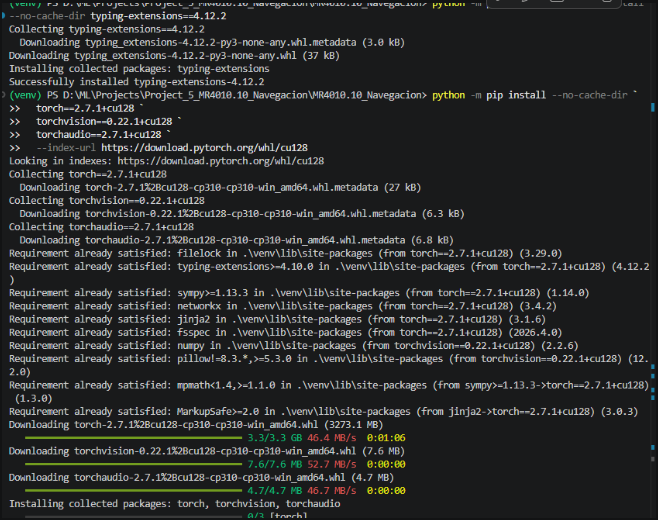

In [7]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# Paso 2 — Cargar bibliotecas

Explicación rápida:

numpy: nos ayuda con matrices, vectores y operaciones matemáticas.

matplotlib: nos ayuda a graficar los datos y la frontera de decisión.

%matplotlib inline: permite que las gráficas aparezcan dentro del notebook.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# TensorFlow incluye Keras integrado
import tensorflow as tf

# Sequential permite agregar capas secuenciales
from tensorflow.keras.models import Sequential

# Dense crea capas completamente conectadas
from tensorflow.keras.layers import Dense

# Adam es el optimizador
from tensorflow.keras.optimizers import Adam

print(r'Tensor flow: ',tf.__version__)

Tensor flow:  2.21.0


## Paso 3 - Cargar dataset

### Se carga como DataFrame un dataset de prueba

Las variables independientes son:

- Distancia al tope
- Altura del tope

La etiqueta de salida es:

- Baja velocidad = 0
- Alta velocidad = 1

In [10]:
# ------------------------------------------------------------
# Se carga el dataset desde un archivo CSV
# ------------------------------------------------------------

speed_data = pd.read_csv("D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\Module4\speed_decision_data.csv")

# Mostrar las primeras filas
speed_data.head()

,Distance From Bump,Height of Bump,Speed
0,0.12,0.22,1
1,0.15,0.28,1
2,0.18,0.25,1
3,0.20,0.30,1
4,0.22,0.27,1


## Paso 4 - Informacion del dataset

### Exploración del dataset

Se revisa:

- Número de registros
- Tipos de datos
- Valores nulos

In [11]:
# ------------------------------------------------------------
# Información general del dataset
# ------------------------------------------------------------

speed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Distance From Bump  60 non-null     float64
 1   Height of Bump      60 non-null     float64
 2   Speed               60 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.5 KB


## Paso 5 - Visualizacion de datos

### Visualización de los datos

Se crea una gráfica de dispersión para observar
cómo se separan las clases.

Cada color representa una categoría de velocidad.

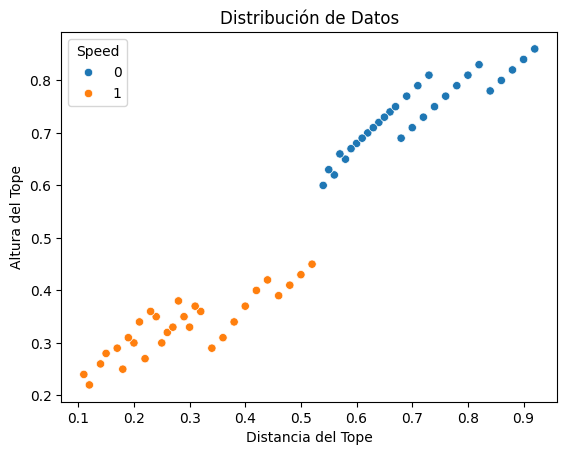

In [13]:
# ------------------------------------------------------------
# Gráfica de dispersión
# ------------------------------------------------------------

sns.scatterplot(
    x=speed_data['Distance From Bump'],
    y=speed_data['Height of Bump'],
    hue=speed_data['Speed']
)

# Títulos de la gráfica
plt.title("Distribución de Datos")
plt.xlabel("Distancia del Tope")
plt.ylabel("Altura del Tope")

plt.show()

## Paso 6 - Craer variables de entrenamiento

### Creación de variables de entrada y salida

X_train contiene las variables independientes.

y_train contiene las etiquetas o clases.

In [15]:
# ------------------------------------------------------------
# Variables independientes
# ------------------------------------------------------------

X_train = speed_data[['Distance From Bump', 'Height of Bump']]

# ------------------------------------------------------------
# Variable dependiente
# ------------------------------------------------------------

y_train = speed_data['Speed']

### Paso 7 - Creacion del modelo

### Construcción de la red neuronal

Se utiliza una sola neurona ya que:

- El problema es de clasificación binaria
- Esto equivale matemáticamente a una regresión logística

Características del modelo:

- 2 entradas
- 1 salida
- Función de activación Sigmoid
- Optimizador Adam
- Función de pérdida Binary Crossentropy

In [16]:
# ------------------------------------------------------------
# Crear modelo secuencial
# ------------------------------------------------------------

model = Sequential()

# ------------------------------------------------------------
# Agregar una sola neurona
# units = 1 -> una salida
# input_dim = 2 -> dos variables de entrada
# activation = sigmoid -> clasificación binaria
# ------------------------------------------------------------

model.add(
    Dense(
        units=1,
        input_dim=2,
        activation='sigmoid'
    )
)

# ------------------------------------------------------------
# Compilar el modelo
# ------------------------------------------------------------

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 8 - Entrenamiento del modelo

### Entrenamiento del modelo

Parámetros utilizados:

- epochs = 100
- batch_size = 50
- shuffle = True

El modelo aprenderá los pesos óptimos
para clasificar correctamente los datos.

In [17]:
# ------------------------------------------------------------
# Entrenamiento del modelo
# ------------------------------------------------------------

hist = model.fit(
    x=X_train,
    y=y_train,
    verbose=2,
    batch_size=50,
    epochs=100,
    shuffle=True
)

Epoch 1/100
2/2 - 0s - 118ms/step - accuracy: 0.5000 - loss: 0.6631
Epoch 2/100
2/2 - 0s - 16ms/step - accuracy: 0.5000 - loss: 0.6597
Epoch 3/100
2/2 - 0s - 14ms/step - accuracy: 0.5000 - loss: 0.6565
Epoch 4/100
2/2 - 0s - 14ms/step - accuracy: 0.5000 - loss: 0.6534
Epoch 5/100
2/2 - 0s - 15ms/step - accuracy: 0.5000 - loss: 0.6503
Epoch 6/100
2/2 - 0s - 13ms/step - accuracy: 0.5000 - loss: 0.6469
Epoch 7/100
2/2 - 0s - 14ms/step - accuracy: 0.5000 - loss: 0.6439
Epoch 8/100
2/2 - 0s - 14ms/step - accuracy: 0.5000 - loss: 0.6408
Epoch 9/100
2/2 - 0s - 14ms/step - accuracy: 0.5000 - loss: 0.6379
Epoch 10/100
2/2 - 0s - 14ms/step - accuracy: 0.5333 - loss: 0.6349
Epoch 11/100
2/2 - 0s - 14ms/step - accuracy: 0.5333 - loss: 0.6320
Epoch 12/100
2/2 - 0s - 16ms/step - accuracy: 0.5333 - loss: 0.6292
Epoch 13/100
2/2 - 0s - 14ms/step - accuracy: 0.5333 - loss: 0.6269
Epoch 14/100
2/2 - 0s - 15ms/step - accuracy: 0.5333 - loss: 0.6244
Epoch 15/100
2/2 - 0s - 15ms/step - accuracy: 0.5333 - l

## Paso 9 - Resumen del modelo

### Resumen de la arquitectura

Se muestran:

- Número de capas
- Número de parámetros
- Dimensiones de entrada y salida

In [18]:
# ------------------------------------------------------------
# Mostrar resumen del modelo
# ------------------------------------------------------------

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

## Paso 10 - Graficar exactitud

### Evolución de la exactitud

Se observa cómo mejora el accuracy
durante el entrenamiento.

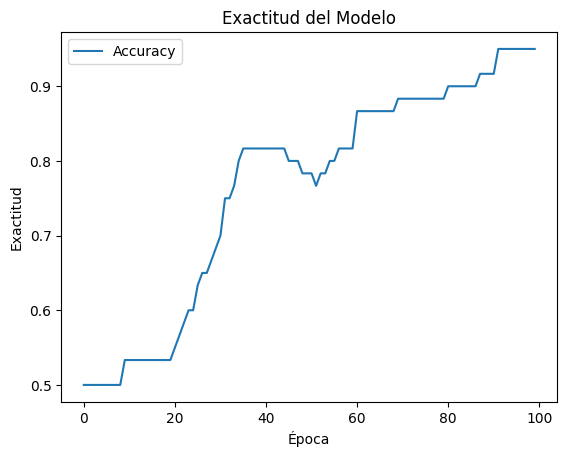

In [19]:
# ------------------------------------------------------------
# Graficar accuracy
# ------------------------------------------------------------

plt.plot(hist.history['accuracy'])

plt.title("Exactitud del Modelo")
plt.ylabel("Exactitud")
plt.xlabel("Época")

plt.legend(['Accuracy'])

plt.show()

## Paso 11 - Graficar error

### Evolución del error

Se visualiza cómo disminuye la función de pérdida.

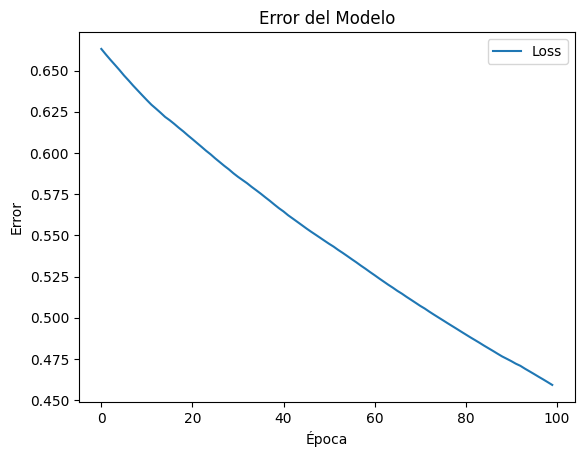

In [20]:
# ------------------------------------------------------------
# Graficar pérdida (loss)
# ------------------------------------------------------------

plt.plot(hist.history['loss'])

plt.title("Error del Modelo")
plt.ylabel("Error")
plt.xlabel("Época")

plt.legend(['Loss'])

plt.show()

## Paso 12 - Visualizar frontera de decision

### Visualización de resultados

Se grafica:

- La frontera de decisión aprendida
- Los puntos reales del dataset

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step


C:\Users\baraj\AppData\Local\Temp\ipykernel_59496\1141165177.py:67: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


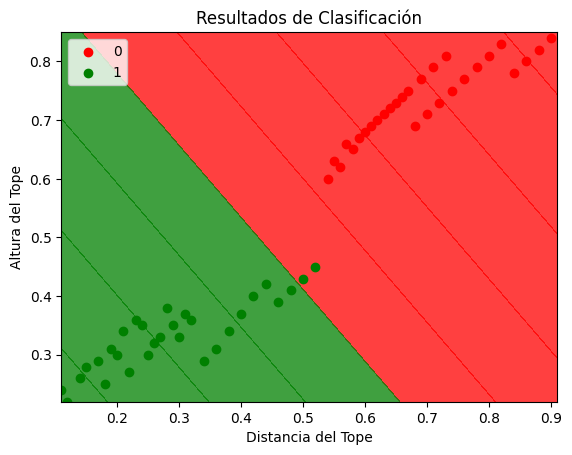

In [21]:
# ------------------------------------------------------------
# Importar colores
# ------------------------------------------------------------

from matplotlib.colors import ListedColormap

# ------------------------------------------------------------
# Convertir datos a arreglos
# ------------------------------------------------------------

X_grid = X_train.values
y_grid = y_train.values

# ------------------------------------------------------------
# Crear malla de puntos
# ------------------------------------------------------------

X1, X2 = np.meshgrid(
    np.arange(
        start=X_grid[:, 0].min(),
        stop=X_grid[:, 0].max(),
        step=0.01
    ),

    np.arange(
        start=X_grid[:, 1].min(),
        stop=X_grid[:, 1].max(),
        step=0.01
    )
)

# ------------------------------------------------------------
# Predicción sobre toda la malla
# ------------------------------------------------------------

predictions = model.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)

predictions = predictions.reshape(X1.shape)

# ------------------------------------------------------------
# Dibujar frontera de decisión
# ------------------------------------------------------------

plt.contourf(
    X1,
    X2,
    predictions,
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

# ------------------------------------------------------------
# Límites de la gráfica
# ------------------------------------------------------------

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# ------------------------------------------------------------
# Dibujar puntos reales
# ------------------------------------------------------------

for i, j in enumerate(np.unique(y_grid)):

    plt.scatter(
        X_grid[y_grid == j, 0],
        X_grid[y_grid == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

# ------------------------------------------------------------
# Etiquetas
# ------------------------------------------------------------

plt.title("Resultados de Clasificación")
plt.xlabel("Distancia del Tope")
plt.ylabel("Altura del Tope")

plt.legend()

plt.show()

## Paso 13 - Mostrar pesos del modelo

### Pesos aprendidos por la neurona

La red neuronal aprende:

- Pesos (weights)
- Biases

In [22]:
# ------------------------------------------------------------
# Obtener pesos y bias
# ------------------------------------------------------------

weights, biases = model.layers[0].get_weights()

# ------------------------------------------------------------
# Mostrar pesos
# ------------------------------------------------------------

print("Pesos aprendidos:")
print(weights)

# ------------------------------------------------------------
# Mostrar bias
# ------------------------------------------------------------

print("\nBias aprendido:")
print(biases)

Pesos aprendidos:
[[-1.5756092]
 [-1.2839125]]

Bias aprendido:
[1.236038]


## Paso 14 - Probar el modelo

### Prueba con un dato arbitrario

Se evalúa una nueva entrada:

- Distancia = 0.1
- Altura = 0.2

El modelo devuelve una probabilidad.

In [23]:
# ------------------------------------------------------------
# Crear nuevo dato
# ------------------------------------------------------------

dist = 0.1
alt = 0.2

dato = np.array([[dist, alt]])

# ------------------------------------------------------------
# Realizar predicción
# ------------------------------------------------------------

prediccion = model.predict(dato)

# ------------------------------------------------------------
# Mostrar resultado
# ------------------------------------------------------------

print("Resultado de la predicción:")
print(prediccion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Resultado de la predicción:
[[0.69459593]]


## Paso 15 - Interpretar la prediccion

### Interpretación de resultados

La salida de Sigmoid representa una probabilidad:

- Cercano a 0 → Baja velocidad
- Cercano a 1 → Alta velocidad

In [24]:
# ------------------------------------------------------------
# Convertir probabilidad a clase
# ------------------------------------------------------------

if prediccion >= 0.5:
    print("Clase predicha: Alta velocidad (1)")
else:
    print("Clase predicha: Baja velocidad (0)")

Clase predicha: Alta velocidad (1)


## Paso 16 - Conclusiones

### Conclusiones

En este notebook se implementó una regresión logística
utilizando Keras y una red neuronal de una sola neurona.

Conceptos aplicados:

- Redes neuronales
- Función Sigmoid
- Binary Crossentropy
- Optimización con Adam
- Entrenamiento supervisado
- Clasificación binaria

La red aprendió correctamente la frontera de decisión
entre las dos clases del dataset.